### Import all packages need in the cell below

In [254]:
using JuMP, Ipopt, HiGHS
using Plots

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

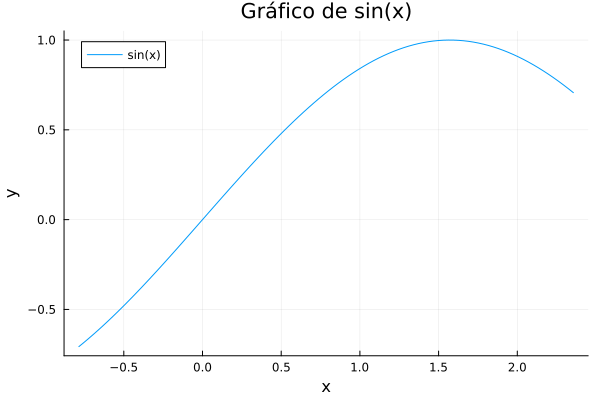

In [255]:
# Definição de intervalo
x = range(-pi/4, 3pi/4, length=100)

# Função
y = sin.(x)

# Plot
plot(x, y, label="sin(x)", xlabel="x", ylabel="y", title="Gráfico de sin(x)")

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

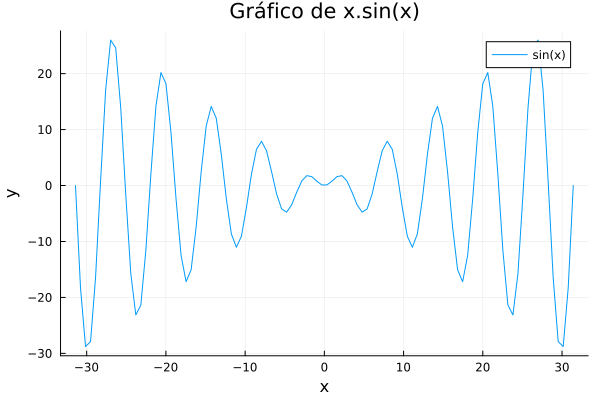

In [256]:
# Definição de intervalo
x = range(-10pi, 10pi, length=100)

# Função
y = x.*sin.(x)

# Plot
plot(x, y, label="sin(x)", xlabel="x", ylabel="y", title="Gráfico de x.sin(x)")

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [257]:
using JuMP
using Ipopt

# Dados do problema
N  = 10.0    # valor da cerveja por m^3
c1 = 2.0     # custo do material da tampa superior por m^2
c2 = 0.5     # fator de custo do material das laterais e fundo

# Criação do modelo
model = Model(Ipopt.Optimizer)

# Variáveis de decisão
# r = raio do tanque
# h = altura do tanque
#
# Colocamos limites inferiores positivos
# para evitar problemas numéricos.
# Também colocamos limites superiores apenas
# para ajudar o solver.
@variable(model, 0.01 <= r <= 10, start = 1.0)
@variable(model, 0.01 <= h <= 10, start = 2.0)

# Expressões auxiliares

# Volume do cilindro
@NLexpression(model, V, π * r^2 * h)

# Área da tampa superior
@NLexpression(model, A_topo, π * r^2)

# Área lateral
@NLexpression(model, A_lateral, 2 * π * r * h)

# Área do fundo
@NLexpression(model, A_fundo, π * r^2)

# Área total das partes cujo custo depende do volume:
# laterais + fundo
@NLexpression(model, A_lateral_fundo, A_lateral + A_fundo)

# Receita total obtida com a cerveja produzida ao longo da vida útil
@NLexpression(model, receita, N * V)

# Custo da tampa superior
@NLexpression(model, custo_topo, c1 * A_topo)

# Custo das laterais e do fundo
# O enunciado diz que esse custo é c2 * V por m²
@NLexpression(model, custo_lateral_fundo, (c2 * V) * A_lateral_fundo)

# Lucro líquido
@NLexpression(model, lucro, receita - custo_topo - custo_lateral_fundo)

# Função objetivo:
# maximizar o lucro líquido

@NLobjective(model, Max, lucro)

# Resolver o problema
optimize!(model)

# Mostrar resultados
println("Status da solução: ", termination_status(model))
println("Raio ótimo r = ", value(r), " m")
println("Altura ótima h = ", value(h), " m")
println("Volume ótimo V = ", value(V), " m^3")
println("Lucro máximo = \$", value(lucro))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        2
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.2006458e+00 0.00e+00 4.48e+01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [258]:
# Dados do problema
h = 2.0
w = 3.0

# Criação do modelo
model = Model(Ipopt.Optimizer)

# Opcional: mostrar mais informações do solver
# set_optimizer_attribute(model, "print_level", 5)

# Variáveis de decisão
# x = distância horizontal da parede até o ponto de ancoragem no solo
# y = altura do ponto de ancoragem na parede
# Como a caixa tem largura w = 3, precisamos de x > 3.
# Colocamos x >= 3.001 para evitar divisão por zero e problemas numéricos.
# Também usamos y >= h = 2, pois o toldo precisa ao menos atingir a altura da caixa.

@variable(model, x >= w + 0.001, start = 4.0)
@variable(model, y >= h,         start = 3.0)

# Expressão do comprimento do toldo
@NLexpression(model, L, sqrt(x^2 + y^2))

# Função objetivo
# Minimizar o comprimento do toldo
@NLobjective(model, Min, L)

# Restrição:
# y * (x - w) >= h * x

# Neste problema:
# y * (x - 3) >= 2x

@NLconstraint(model, y * (x - w) >= h * x)

# Resolver o problema
optimize!(model)

# Resultados
println("Status da solução: ", termination_status(model))
println("x ótimo = ", value(x), " m")
println("y ótimo = ", value(y), " m")
println("Comprimento mínimo do toldo = ", value(L), " m")

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.0000000e+00 5.00e+00 8.67e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Packing Problem

In [259]:
# Dado do problema
A_max = 60.0   # área máxima de papelão disponível (cm^2)

# Criação do modelo
model = Model(Ipopt.Optimizer)

# Variáveis de decisão

# h = altura da caixa
# w = largura da caixa
# d = profundidade da caixa
#
# Colocamos limites inferiores pequenos e positivos
# para evitar problemas numéricos no solver.
# Também definimos valores iniciais.

@variable(model, h >= 0.001, start = 2.0)
@variable(model, w >= 0.001, start = 2.0)
@variable(model, d >= 0.001, start = 2.0)


# Expressão do volume

@NLexpression(model, V, h * w * d)


# Função objetivo
# Maximizar o volume da caixa

@NLobjective(model, Max, V)


# Restrição de área de papelão

# Faces:
# - frente e trás: 2*h*w
# - laterais: 2*h*d
# - superior e inferior com triplo do peso:
#   3*w*d + 3*w*d = 6*w*d
#
# Total:
# 2*h*w + 2*h*d + 6*w*d <= 60

@NLconstraint(model, 2*h*w + 2*h*d + 6*w*d <= A_max)


# Resolver o problema
optimize!(model)

# Mostrar resultados
println("Status da solução: ", termination_status(model))
println("Altura ótima h = ", value(h), " cm")
println("Largura ótima w = ", value(w), " cm")
println("Profundidade ótima d = ", value(d), " cm")
println("Volume máximo = ", value(V), " cm^3")

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        3
Number of nonzeros in Lagrangian Hessian.............:       12

Total number of variables............................:        3
                     variables with only lower bounds:        3
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  8.0000000e+00 0.00e+00 2.21e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

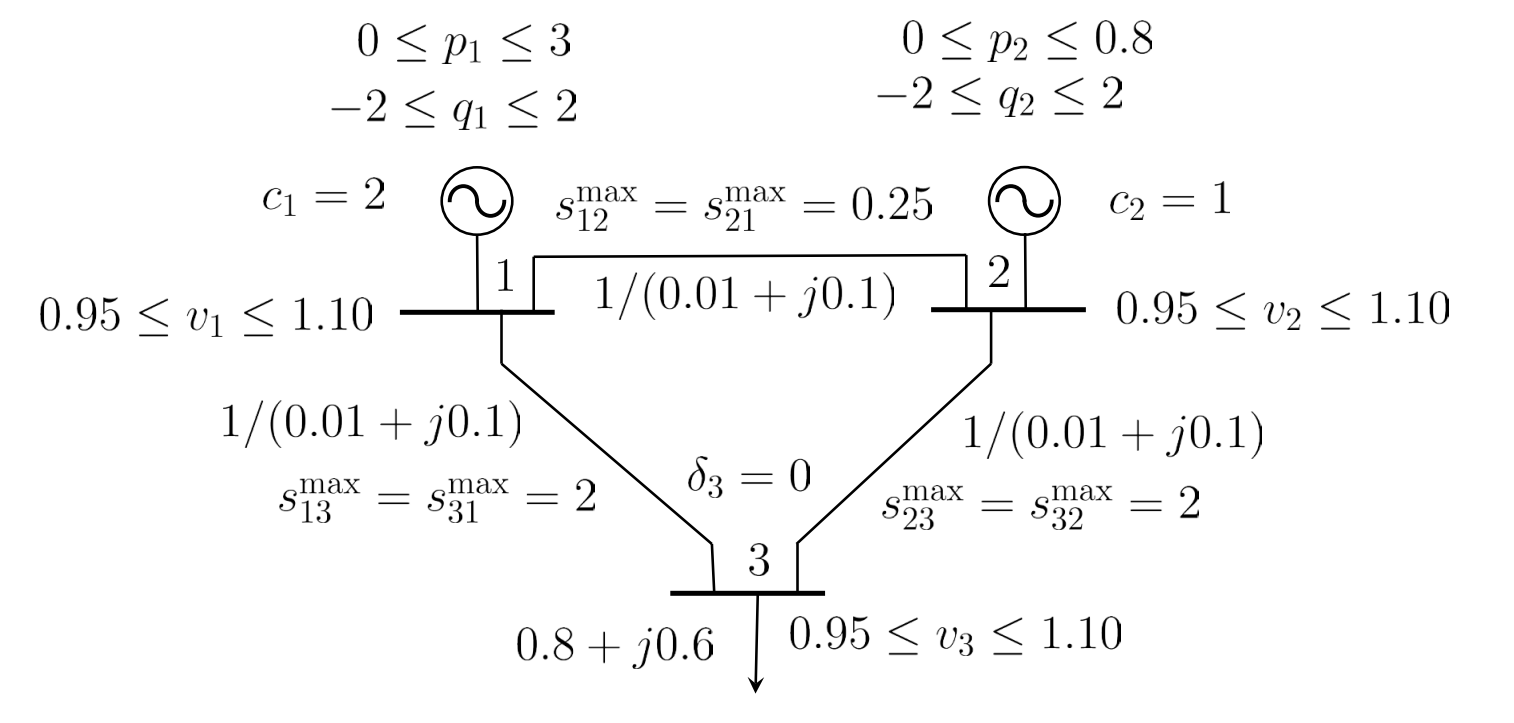

In [ ]:
using JuMP
using Ipopt
using LinearAlgebra

# DADOS DO PROBLEMA
nb = 3

z = 0.01 + 0.1im
y = 1 / z

g = real(y)
b = imag(y)

# Matriz Ybus
Y = zeros(ComplexF64, nb, nb)

# Linha 1-2
Y[1,1] += y
Y[2,2] += y
Y[1,2] += -y
Y[2,1] += -y

# Linha 1-3
Y[1,1] += y
Y[3,3] += y
Y[1,3] += -y
Y[3,1] += -y

# Linha 2-3
Y[2,2] += y
Y[3,3] += y
Y[2,3] += -y
Y[3,2] += -y

G = real.(Y)
B = imag.(Y)

# Cargas
Pd = [0.0, 0.0, 0.8]
Qd = [0.0, 0.0, 0.6]

# Custos
c = [2.0, 1.0, 0.0]

# Limites de geração
Pmin = [0.0, 0.0, 0.0]
Pmax = [3.0, 0.8, 0.0]

Qmin = [-2.0, -2.0, 0.0]
Qmax = [ 2.0,  2.0, 0.0]

# Limites de tensão
Vmin = [0.95, 0.95, 0.95]
Vmax = [1.10, 1.10, 1.10]

# Limites de fluxo aparente
Smax = Dict(
    (1,2) => 0.25,
    (2,1) => 0.25,
    (1,3) => 2.0,
    (3,1) => 2.0,
    (2,3) => 2.0,
    (3,2) => 2.0
)

arcs = [(1,2), (2,1), (1,3), (3,1), (2,3), (3,2)]

# MODELO
model = Model(Ipopt.Optimizer)

# Desliga a saída detalhada do Ipopt
set_optimizer_attribute(model, "print_level", 0)
set_optimizer_attribute(model, "sb", "yes")

# VARIÁVEIS
@variable(model, Pmin[i] <= pg[i=1:nb] <= Pmax[i], start = 0.2)
@variable(model, Qmin[i] <= qg[i=1:nb] <= Qmax[i], start = 0.0)
@variable(model, Vmin[i] <= v[i=1:nb] <= Vmax[i], start = 1.0)
@variable(model, delta[1:nb], start = 0.0)

# Barra de referência
fix(delta[3], 0.0; force = true)

# Barra 3 não gera
fix(pg[3], 0.0; force = true)
fix(qg[3], 0.0; force = true)

# FUNÇÃO OBJETIVO
@objective(model, Min, sum(c[i] * pg[i] for i in 1:nb))

# BALANÇO DE POTÊNCIA
@NLconstraint(model, [i=1:nb],
    pg[i] - Pd[i] ==
    sum(
        v[i] * v[j] *
        (G[i,j] * cos(delta[i] - delta[j]) +
         B[i,j] * sin(delta[i] - delta[j]))
        for j in 1:nb
    )
)

@NLconstraint(model, [i=1:nb],
    qg[i] - Qd[i] ==
    sum(
        v[i] * v[j] *
        (G[i,j] * sin(delta[i] - delta[j]) -
         B[i,j] * cos(delta[i] - delta[j]))
        for j in 1:nb
    )
)


# FLUXOS NAS LINHAS

@NLexpression(model, Pflow[i=1:nb, j=1:nb; i != j],
    g * v[i]^2 -
    v[i] * v[j] * (
        g * cos(delta[i] - delta[j]) +
        b * sin(delta[i] - delta[j])
    )
)

@NLexpression(model, Qflow[i=1:nb, j=1:nb; i != j],
    -b * v[i]^2 -
    v[i] * v[j] * (
        g * sin(delta[i] - delta[j]) -
        b * cos(delta[i] - delta[j])
    )
)

@NLconstraint(model, [(i,j) in arcs],
    Pflow[i,j]^2 + Qflow[i,j]^2 <= Smax[(i,j)]^2
)

# RESOLVER
optimize!(model)

# RESULTADOS
println("\n================ RESULTADOS ================\n")
println("Status da solução: ", termination_status(model))
println("Custo mínimo = ", objective_value(model))
println()

println("Geração ótima:")
for i in 1:nb
    println("Barra ", i,
            ": pg = ", value(pg[i]),
            " pu, qg = ", value(qg[i]), " pu")
end

println()
println("Tensões ótimas:")
for i in 1:nb
    println("Barra ", i,
            ": v = ", value(v[i]),
            " pu, delta = ", value(delta[i]), " rad")
end

println()
println("Fluxos nas linhas:")
for (i,j) in arcs
    println("Linha ", i, " -> ", j,
            ": P = ", value(Pflow[i,j]),
            ", Q = ", value(Qflow[i,j]),
            ", |S| = ", sqrt(value(Pflow[i,j])^2 + value(Qflow[i,j])^2),
            ", limite = ", Smax[(i,j)])
end


================ RESULTADOS ================

Status da solução: LOCALLY_SOLVED
Custo mínimo = 0.8360786945615197

Geração ótima:
Barra 1: pg = 0.030906834553260903 pu, qg = 0.32091669238597054 pu
Barra 2: pg = 0.774265025454998 pu, qg = 0.33080190769662504 pu
Barra 3: pg = 0.0 pu, qg = 0.0 pu

Tensões ótimas:
Barra 1: v = 1.097700192705261 pu, delta = 0.021231966882032376 rad
Barra 2: v = 1.0999998938295108 pu, delta = 0.041912659955651854 rad
Barra 3: v = 1.0663591316422727 pu, delta = 0.0 rad

Fluxos nas linhas:
Linha 1 -> 2: P = -0.24946689528744503, Q = 0.002284894689775996, |S| = 0.2494773588686966, limite = 0.25
Linha 2 -> 1: P = 0.24998342438840981, Q = 0.0028803963198704707, |S| = 0.25000001830383, limite = 0.25
Linha 1 -> 3: P = 0.2803737298407264, Q = 0.3186317976961526, |S| = 0.42442390470834995, limite = 2.0
Linha 3 -> 1: P = -0.2788787608231622, Q = -0.3036821075205083, |S| = 0.41230593697685225, limite = 2.0
Linha 2 -> 3: P = 0.5242816010665576, Q = 0.3279215113769087, 

# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [261]:

# Dados do problema
# Vetores com os dados observados
x1 = [1.0, 2.0, 3.0, 4.0, 5.0]
x2 = [0.5, 1.0, 1.5, 2.0, 2.5]
x3 = [1.2, 2.1, 2.9, 3.8, 4.5]
y  = [2.0, 3.9, 6.1, 8.0, 9.8]

# Número de observações
n = length(y)


# Criação do modelo
model = Model(Ipopt.Optimizer)

# Variáveis de decisão
# β0 = intercepto
# β1, β2, β3 = coeficientes da regressão
@variable(model, β0, start = 0.0)
@variable(model, β1, start = 0.0)
@variable(model, β2, start = 0.0)
@variable(model, β3, start = 0.0)


# Expressão dos resíduos
# res[i] = erro da observação i
#        = y[i] - valor previsto pelo modelo
@expression(model, res[i=1:n], y[i] - (β0 + β1*x1[i] + β2*x2[i] + β3*x3[i]))

# Função objetivo
# Minimizar a soma dos quadrados dos resíduos:
# min Σ res[i]^2
@objective(model, Min, sum(res[i]^2 for i in 1:n))

# Resolver o problema
optimize!(model)

# Mostrar resultados
println("Status da solução: ", termination_status(model))
println("β0 = ", value(β0))
println("β1 = ", value(β1))
println("β2 = ", value(β2))
println("β3 = ", value(β3))
println("Soma dos quadrados dos resíduos = ", objective_value(model))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       10

Total number of variables............................:        4
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.1646000e+02 0.00e+00 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [262]:
# DADOS DO PROBLEMA
# Número de designers e projetos
num_designers = 3
num_projects = 4

# Pontuações de capacidade
# score[i,j] = pontuação do designer i no projeto j
score = [
    90  80  10  50;
    60  70  50  65;
    70  40  80  85
]

# Horas requeridas por cada projeto
required_hours = [70, 50, 85, 35]

# Horas disponíveis por designer
available_hours = [80, 80, 80]

# CRIAÇÃO DO MODELO
model = Model(HiGHS.Optimizer)

# VARIÁVEIS DE DECISÃO
# x[i,j] = número de horas que o designer i
# dedica ao projeto j
@variable(model, x[1:num_designers, 1:num_projects] >= 0)


# FUNÇÃO OBJETIVO
==
# Maximizar a pontuação total de contribuição:
# soma de (pontuação × horas alocadas)

@objective(model, Max,
    sum(score[i,j] * x[i,j] for i in 1:num_designers, j in 1:num_projects)
)


# RESTRIÇÕES DE DISPONIBILIDADE DOS DESIGNERS

# Cada designer pode trabalhar no máximo 80 horas

@constraint(model, [i in 1:num_designers],
    sum(x[i,j] for j in 1:num_projects) <= available_hours[i]
)


# RESTRIÇÕES DE DEMANDA DOS PROJETOS
# Cada projeto deve receber exatamente o número
# de horas exigido
@constraint(model, [j in 1:num_projects],
    sum(x[i,j] for i in 1:num_designers) == required_hours[j]
)

# RESOLVER O MODELO

optimize!(model)

# RESULTADOS
println("Status da solução: ", termination_status(model))
println("Pontuação total máxima = ", objective_value(model))
println()

println("Horas alocadas (designer x projeto):")
for i in 1:num_designers
    for j in 1:num_projects
        println("Designer ", i, " -> Projeto ", j, ": ", value(x[i,j]), " horas")
    end
end

println()
println("Resumo por designer:")
for i in 1:num_designers
    println("Designer ", i, ": ", sum(value(x[i,j]) for j in 1:num_projects), " horas")
end

println()
println("Resumo por projeto:")
for j in 1:num_projects
    println("Projeto ", j, ": ", sum(value(x[i,j]) for i in 1:num_designers), " horas")
end

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 7 rows; 12 cols; 24 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+01, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 8e+01]
Presolving model
7 rows, 12 cols, 24 nonzeros  0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
7 rows, 12 cols, 24 nonzeros  0s
Presolve reductions: rows 7(-0); columns 12(-0); nonzeros 24(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.4995459328e+02 Ph1: 7(24); Du: 12(749.955) 0.0s
          7     1.8825000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.8825000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time 

# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [263]:
# DADOS DO PROBLEMA

# Custo de cada alimento
# y1 = apple
# y2 = bread
# y3 = milk
# y4 = egg
cost = [1.0, 0.5, 2.0, 0.3]

# Conteúdo nutricional por unidade
calories = [100.0, 200.0, 150.0, 70.0]
protein  = [0.5,   4.0,   8.0,   6.0]
vitamins = [2.0,   0.0,   10.0,  0.0]

# Requisitos mínimos diários
min_calories = 500.0
min_protein  = 50.0
min_vitamins = 100.0

# Número de alimentos
n = 4

# CRIAÇÃO DO MODELO

model = Model(HiGHS.Optimizer)

# VARIÁVEIS DE DECISÃO

# y[i] = quantidade do alimento i
#
# Índices:
# y[1] = maçã
# y[2] = pão
# y[3] = leite
# y[4] = ovo

@variable(model, y[1:n] >= 0)


# FUNÇÃO OBJETIVO

# Minimizar o custo total da dieta

@objective(model, Min, sum(cost[i] * y[i] for i in 1:n))


# RESTRIÇÃO DE CALORIAS

@constraint(model,
    sum(calories[i] * y[i] for i in 1:n) >= min_calories
)


# RESTRIÇÃO DE PROTEÍNA
@constraint(model,
    sum(protein[i] * y[i] for i in 1:n) >= min_protein
)


# RESTRIÇÃO DE VITAMINAS
@constraint(model,
    sum(vitamins[i] * y[i] for i in 1:n) >= min_vitamins
)


# RESOLVER O MODELO
optimize!(model)

# MOSTRAR RESULTADOS
println("Status da solução: ", termination_status(model))
println("Custo mínimo = \$", objective_value(model))
println()

println("Quantidades ótimas:")
println("Maçã (y1)  = ", value(y[1]))
println("Pão   (y2) = ", value(y[2]))
println("Leite (y3) = ", value(y[3]))
println("Ovo   (y4) = ", value(y[4]))
println()

println("Totais nutricionais obtidos:")
println("Calorias = ", sum(calories[i] * value(y[i]) for i in 1:n))
println("Proteína = ", sum(protein[i]  * value(y[i]) for i in 1:n))
println("Vitaminas = ", sum(vitamins[i] * value(y[i]) for i in 1:n))

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 3 rows; 4 cols; 10 nonzeros
Coefficient ranges:
  Matrix  [5e-01, 2e+02]
  Cost    [3e-01, 2e+00]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 5e+02]
Presolving model
3 rows, 4 cols, 10 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-3); columns 0(-4); nonzeros 0(-10) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  2.0000000000e+01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Status da solução: OPTIMAL
Custo mínimo = $20.0

Quantidades ótimas:
Maçã (y1)  = 0.0
Pão   (y2) = 0.0
Leite (y3) = 10.0
Ovo   (y4) = 0.0

Totais nutricionais obtidos:
Calorias = 1500.0
Proteína = 80.0
Vitaminas = 100.0


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [264]:
# DADOS DO PROBLEMA

# Valores dos itens
# x1 = barraca
# x2 = fogareiro
# x3 = comida
values = [120, 80, 60]

# Pesos dos itens
weights = [2.0, 1.0, 1.0]

# Capacidade máxima da mochila
capacity = 3.5

# Número de itens
n = 3

# CRIAÇÃO DO MODELO
model = Model(HiGHS.Optimizer)

# VARIÁVEIS DE DECISÃO

# x[i] = 1 se o item i for escolhido
# x[i] = 0 caso contrário
@variable(model, x[1:n], Bin)


# FUNÇÃO OBJETIVO
# Maximizar o valor total dos itens escolhidos
@objective(model, Max, sum(values[i] * x[i] for i in 1:n))


# RESTRIÇÃO DE CAPACIDADE
# O peso total não pode ultrapassar a capacidade
# da mochila
@constraint(model, sum(weights[i] * x[i] for i in 1:n) <= capacity)

# RESOLVER O MODELO
optimize!(model)

# MOSTRAR RESULTADOS
println("Status da solução: ", termination_status(model))
println("Valor máximo = ", objective_value(model))
println()

println("Itens escolhidos:")
println("Barraca (x1)    = ", value(x[1]))
println("Fogareiro (x2)  = ", value(x[2]))
println("Comida (x3)     = ", value(x[3]))
println()

println("Peso total = ", sum(weights[i] * value(x[i]) for i in 1:n), " kg")
println("Valor total = ", sum(values[i] * value(x[i]) for i in 1:n))

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1 row; 3 cols; 3 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 4e+00]
Presolving model
1 rows, 3 cols, 3 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-1); columns 0(-3); nonzeros 0(-3) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc.